In [157]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
#The set_option command lets us view all columns when inspecting the DataFrame.

In [158]:
df = pd.read_csv("/Users/saranraj/PycharmProjects/house_price_prediction/data/cleaned_house_data.csv")

In [159]:
print(df.shape)

df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [160]:
print(("missing values"),df.isnull().sum())
#just verifying the values again that it doesnot have any missing values

missing values Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Mo Sold           0
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Length: 82, dtype: int64


In [161]:
#we are looking into it because the total area is the matter so that we need to predict based on the tota area so we are doing this.

df["TotalSF"] = (
    df["1st Flr SF"] +
    df["2nd Flr SF"] +
    df["Total Bsmt SF"]
)

#Instead of forcing the model to combine three different columns, we create one meaningful feature.

In [162]:
df[[
    "1st Flr SF",
    "2nd Flr SF",
    "Total Bsmt SF",
    "TotalSF"
]].head()

,1st Flr SF,2nd Flr SF,Total Bsmt SF,TotalSF
0,1656,0,1080.0,2736.0
1,896,0,882.0,1778.0
2,1329,0,1329.0,2658.0
3,2110,0,2110.0,4220.0
4,928,701,928.0,2557.0


We keep the original features because they may still contain useful information. Some models can learn different relationships from individual floor areas as well as the combined total. We can later compare model performance and decide whether to retain or remove them.

In [163]:
correlation = df[["TotalSF", "SalePrice"]].corr()
correlation

,TotalSF,SalePrice
TotalSF,1.000000,0.793127
SalePrice,0.793127,1.000000


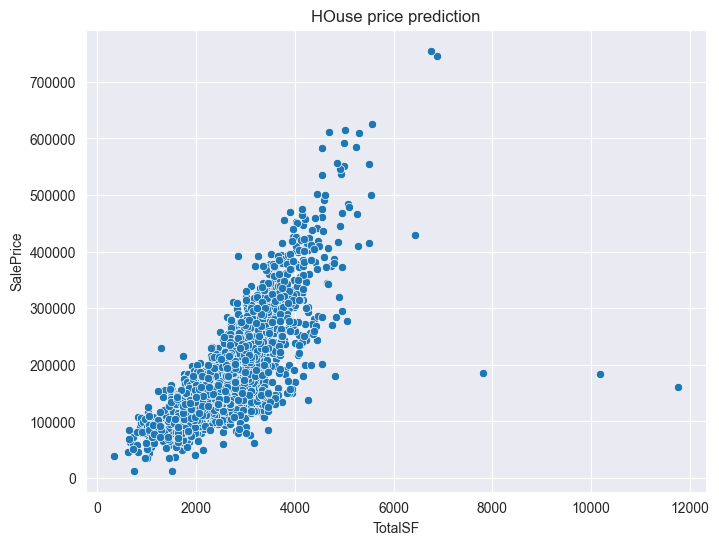

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data= df,
    x="TotalSF",
    y="SalePrice",
)
plt.title("HOuse price prediction")
plt.xlabel("TotalSF")
plt.ylabel("SalePrice")
plt.show()

In [165]:
df["TotalBath"] = (
    df["Full Bath"] +
    0.5 * df["Half Bath"] +
    df["Bsmt Full Bath"] +
    0.5 * df["Bsmt Half Bath"]
)

In [166]:
df[[
    "Full Bath",
    "Half Bath",
    "Bsmt Full Bath",
    "Bsmt Half Bath",
    "TotalBath"
]].head()

,Full Bath,Half Bath,Bsmt Full Bath,Bsmt Half Bath,TotalBath
0,1,0,1.0,0.0,2.0
1,1,0,0.0,0.0,1.0
2,1,1,0.0,0.0,1.5
3,2,1,1.0,0.0,3.5
4,2,1,0.0,0.0,2.5


In [167]:
df[["TotalBath", "SalePrice"]].corr()

,TotalBath,SalePrice
TotalBath,1.000000,0.636175
SalePrice,0.636175,1.000000


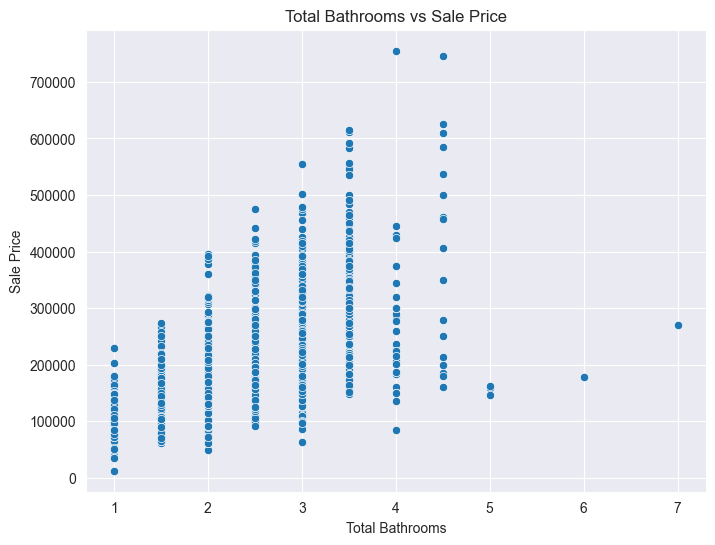

In [168]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="TotalBath",
    y="SalePrice"
)

plt.title("Total Bathrooms vs Sale Price")
plt.xlabel("Total Bathrooms")
plt.ylabel("Sale Price")

plt.show()

In [169]:
#to predict the price we also need to analyse the year of bilt and sold

df["HouseAge"] = df["Yr Sold"] - df["Year Built"]

In [170]:
df[[
    "Year Built",
    "Yr Sold",
    "HouseAge"
]].head()

,Year Built,Yr Sold,HouseAge
0,1960,2010,50
1,1961,2010,49
2,1958,2010,52
3,1968,2010,42
4,1997,2010,13


In [171]:
df[["HouseAge", "SalePrice"]].corr()

,HouseAge,SalePrice
HouseAge,1.000000,-0.558907
SalePrice,-0.558907,1.000000


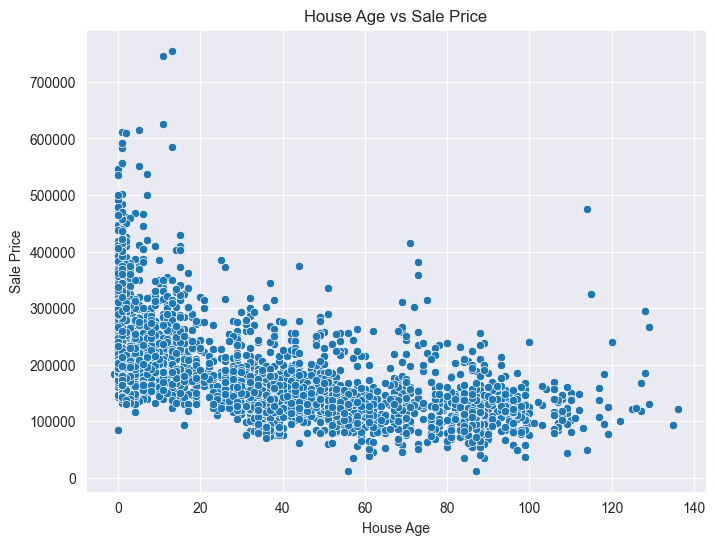

In [172]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="HouseAge",
    y="SalePrice"
)

plt.title("House Age vs Sale Price")
plt.xlabel("House Age")
plt.ylabel("Sale Price")

plt.show()

In [173]:
df["RemodAge"] = df["Yr Sold"] - df["Year Remod/Add"]

In [174]:
df[[
    "Year Remod/Add",
    "Yr Sold",
    "RemodAge"
]].head()

,Year Remod/Add,Yr Sold,RemodAge
0,1960,2010,50
1,1961,2010,49
2,1958,2010,52
3,1968,2010,42
4,1998,2010,12


In [175]:
df[["RemodAge", "SalePrice"]].corr()

,RemodAge,SalePrice
RemodAge,1.00000,-0.53494
SalePrice,-0.53494,1.00000


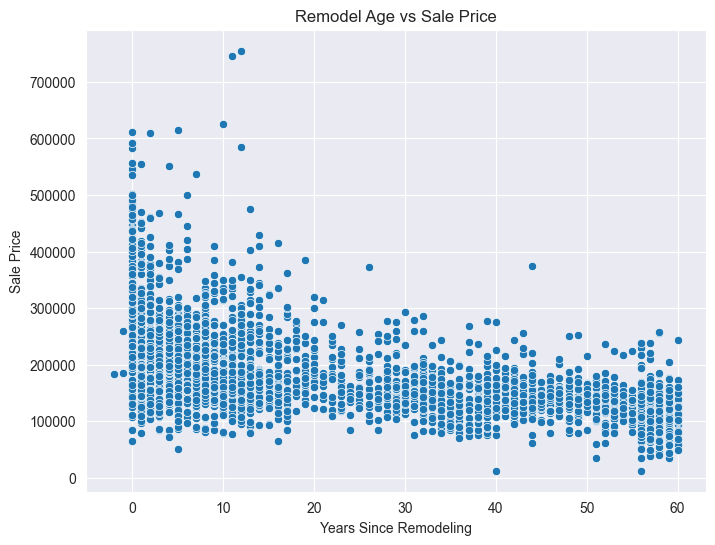

In [176]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="RemodAge",
    y="SalePrice"
)

plt.title("Remodel Age vs Sale Price")
plt.xlabel("Years Since Remodeling")
plt.ylabel("Sale Price")

plt.show()

"Year Remod/Add is an absolute calendar year, but RemodAge measures how many years had passed between the renovation and the sale. This is more directly related to how buyers perceive the condition of the house


In [177]:
df["IsRemodeled"] = (
    df["Year Built"] != df["Year Remod/Add"]
).astype(int)

In [178]:
df[[
    "Year Built",
    "Year Remod/Add",
    "IsRemodeled"
]].head(10)

,Year Built,Year Remod/Add,IsRemodeled
0,1960,1960,0
1,1961,1961,0
2,1958,1958,0
3,1968,1968,0
4,1997,1998,1
5,1998,1998,0
6,2001,2001,0
7,1992,1992,0
8,1995,1996,1
9,1999,1999,0


In [179]:
df["IsRemodeled"].value_counts()

IsRemodeled
0    1569
1    1361
Name: count, dtype: int64

In [180]:
df["TotalPorchSF"] = (
    df["Open Porch SF"] +
    df["Enclosed Porch"] +
    df["3Ssn Porch"] +
    df["Screen Porch"]
)

#combined different porch types into one feature because buyers are generally influenced by the total usable outdoor living space rather than individual porch categories.

In [181]:
df[[
    "Open Porch SF",
    "Enclosed Porch",
    "3Ssn Porch",
    "Screen Porch",
    "TotalPorchSF"
]].head()

,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,TotalPorchSF
0,62,0,0,0,62
1,0,0,0,120,120
2,36,0,0,0,36
3,0,0,0,0,0
4,34,0,0,0,34


In [182]:
df[["TotalPorchSF", "SalePrice"]].corr()

,TotalPorchSF,SalePrice
TotalPorchSF,1.000000,0.185263
SalePrice,0.185263,1.000000


In [183]:
df["HasGarage"] = (df["Garage Area"] > 0).astype(int)

In [184]:
df["HasGarage"].value_counts()

HasGarage
1    2772
0     158
Name: count, dtype: int64

In [185]:
df["HasBasement"] = (df["Total Bsmt SF"] > 0).astype(int)

In [186]:
df["HasBasement"].value_counts()

HasBasement
1    2850
0      80
Name: count, dtype: int64

In [187]:
df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)

In [188]:
df["HasFireplace"].value_counts()

HasFireplace
1    1508
0    1422
Name: count, dtype: int64

In [189]:
new_features = [
    "TotalSF",
    "TotalBath",
    "HouseAge",
    "RemodAge",
    "IsRemodeled",
    "TotalPorchSF",
    "HasGarage",
    "HasBasement",
    "HasFireplace"
]

df[new_features].head()

,TotalSF,TotalBath,HouseAge,RemodAge,IsRemodeled,TotalPorchSF,HasGarage,HasBasement,HasFireplace
0,2736.0,2.0,50,50,0,62,1,1,1
1,1778.0,1.0,49,49,0,120,1,1,0
2,2658.0,1.5,52,52,0,36,1,1,0
3,4220.0,3.5,42,42,0,0,1,1,1
4,2557.0,2.5,13,12,1,34,1,1,1


In [190]:
engineered_corr = (
    df[new_features + ["SalePrice"]]
    .corr()["SalePrice"]
    .sort_values(ascending=False)
)

engineered_corr

SalePrice       1.000000
TotalSF         0.793127
TotalBath       0.636175
HasFireplace    0.481446
HasGarage       0.225840
TotalPorchSF    0.185263
HasBasement     0.154369
IsRemodeled    -0.047274
RemodAge       -0.534940
HouseAge       -0.558907
Name: SalePrice, dtype: float64

In [191]:
df.to_csv("/Users/saranraj/PycharmProjects/house_price_prediction/data/featured_house_data.csv", index=False)

print("Feature engineered dataset saved successfully!")

Feature engineered dataset saved successfully!
